# Offline Study Assistant: evaluation analysis

Reads the phone exports in `eval/results/` and produces the metrics table and the charts used in `docs/METRICS.md` and the README.

- **Retrieval:** `retrieval_{vector,hybrid,keyword}_*.json` (retrieval eval screen, 50 answerable questions).
- **Answers:** `answers_*.json` (answer eval screen, all 60 questions through the app's pipeline).
- **Prefill:** `prompt_sweep_*.json` (LLM benchmark screen, time to first token against prompt size).
- **Hand grades (optional):** `grades.json`, see the last section.

All numbers come from the Galaxy A16 (SM-A165F), release build. Only `json` and `matplotlib` are needed. Run from the repo root or from `eval/`; charts are saved to `docs/charts/`.

In [1]:
import json
import statistics
from pathlib import Path

import matplotlib.pyplot as plt
from IPython.display import Markdown, display

ROOT = Path.cwd() if (Path.cwd() / 'eval').is_dir() else Path.cwd().parent
RESULTS = ROOT / 'eval' / 'results'
CHARTS = ROOT / 'docs' / 'charts'
CHARTS.mkdir(parents=True, exist_ok=True)


def load(path):
    return json.loads(path.read_text(encoding='utf-8'))


def latest(pattern):
    # Exports are named <kind>_<yyyymmdd-hhmmss>.json, so the last one sorted is the newest.
    matches = sorted(RESULTS.glob(pattern))
    if not matches:
        raise FileNotFoundError(f'no {pattern} in {RESULTS}')
    return matches[-1]


retrieval_files = {m: latest(f'retrieval_{m}_*.json') for m in ('vector', 'hybrid', 'keyword')}
retrieval = {m: load(p) for m, p in retrieval_files.items()}
answers_file = latest('answers_*.json')
answers = load(answers_file)
sweep_file = latest('prompt_sweep_*.json')
sweep = load(sweep_file)

for name, path in [*retrieval_files.items(), ('answers', answers_file), ('sweep', sweep_file)]:
    print(f'{name:8} {path.name}')

vector   retrieval_vector_20261001-201837.json
hybrid   retrieval_hybrid_20261001-201612.json
keyword  retrieval_keyword_20261001-201851.json
answers  answers_20261001-224516.json
sweep    prompt_sweep_20261001-211618.json


In [2]:
# Chart style: light surface, recessive grid and axes, text in ink colors (never series colors).
SURFACE = '#fcfcfb'
INK = '#0b0b0b'
INK_2 = '#52514e'
GRID = '#e4e3df'
# Categorical slots 1-3 of the reference palette (validated all-pairs for colorblind readers).
SERIES = {'vector': '#2a78d6', 'hybrid': '#eb6834', 'keyword': '#1baf7a'}

plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'savefig.facecolor': SURFACE,
    'axes.edgecolor': GRID, 'axes.labelcolor': INK_2, 'axes.titlecolor': INK,
    'axes.titlesize': 13, 'axes.titleweight': 'bold', 'axes.titlelocation': 'left',
    'axes.spines.top': False, 'axes.spines.right': False, 'axes.spines.left': False,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8,
    'xtick.color': INK_2, 'ytick.color': INK_2, 'xtick.major.size': 0, 'ytick.major.size': 0,
    'font.size': 10.5, 'legend.frameon': False, 'figure.dpi': 110,
})


def save(fig, name):
    fig.savefig(CHARTS / name, dpi=160, bbox_inches='tight')
    print(f'saved docs/charts/{name}')

## Retrieval: Recall@5 by method

A question is found when a chunk from the right document and page is in the top 5 (`rank` ≤ 5). Questions are split by whether they are asked in the document's language: about half the set is cross-language on purpose (English questions on French documents and the reverse).

In [3]:
# Language of each eval document (the questions file only records the question's language).
DOC_LANG = {
    'ps_game__Copy_': 'fr', 'etat_de_l_art': 'fr',
    '01_ai_fundamentals': 'en', '02_rag_basics': 'en', '03_rag_architecture': 'en',
}
K = 5


def recall_rows(report):
    qs = [r for r in report['results'] if r['answerable']]
    found = lambda r: r['rank'] is not None and r['rank'] <= K
    same = [r for r in qs if r['lang'] == DOC_LANG[r['doc']]]
    cross = [r for r in qs if r['lang'] != DOC_LANG[r['doc']]]
    mrr = sum(1 / r['rank'] for r in qs if found(r)) / len(qs)
    return {
        'n': len(qs), 'found': sum(map(found, qs)), 'mrr': mrr,
        'same': (sum(map(found, same)), len(same)),
        'cross': (sum(map(found, cross)), len(cross)),
        'latency_ms': statistics.median(r['latency_ms'] for r in qs),
    }


recall = {m: recall_rows(r) for m, r in retrieval.items()}

# The numbers must match the summaries the app wrote.
for m, row in recall.items():
    s = retrieval[m]['summary']
    assert row['found'] == s['found'] and abs(row['mrr'] - s['mrr']) < 1e-3, m

LABELS = {'vector': 'Vector only', 'hybrid': 'Hybrid (RRF)', 'keyword': 'Keyword only (BM25)'}
lines = ['| Method | Recall@5 | MRR | Same-language | Cross-language | Median latency |',
         '|---|---|---|---|---|---|']
for m, row in recall.items():
    lines.append(
        f"| {LABELS[m]} | **{row['found'] / row['n']:.1%}** ({row['found']}/{row['n']}) | {row['mrr']:.3f} "
        f"| {row['same'][0]}/{row['same'][1]} | {row['cross'][0]}/{row['cross'][1]} "
        f"| {row['latency_ms'] / 1000:.2f} s |")
display(Markdown('\n'.join(lines)))

| Method | Recall@5 | MRR | Same-language | Cross-language | Median latency |
|---|---|---|---|---|---|
| Vector only | **90.0%** (45/50) | 0.687 | 25/26 | 20/24 | 2.10 s |
| Hybrid (RRF) | **84.0%** (42/50) | 0.649 | 26/26 | 16/24 | 2.11 s |
| Keyword only (BM25) | **60.0%** (30/50) | 0.492 | 24/26 | 6/24 | 0.01 s |

saved docs/charts/recall_by_method.png


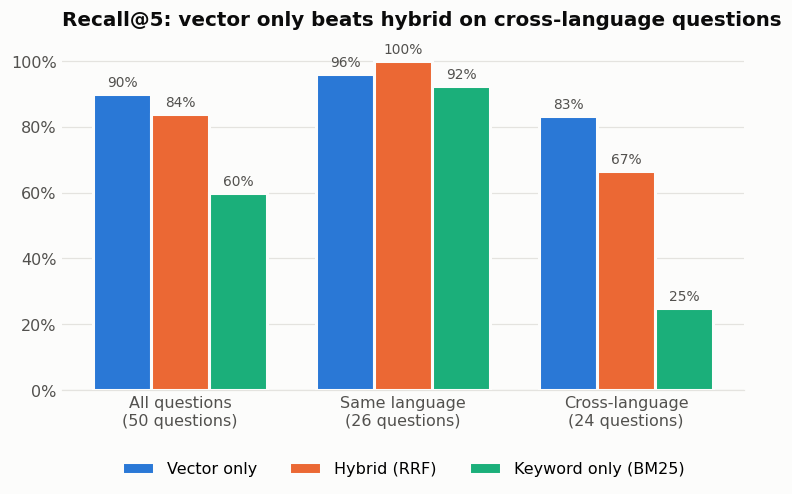

In [4]:
groups = ['All questions', 'Same language', 'Cross-language']


def rates(row):
    return [row['found'] / row['n'], row['same'][0] / row['same'][1], row['cross'][0] / row['cross'][1]]


fig, ax = plt.subplots(figsize=(8, 4.2))
width = 0.26
for i, m in enumerate(recall):
    xs = [g + (i - 1) * width for g in range(len(groups))]
    bars = ax.bar(xs, rates(recall[m]), width, color=SERIES[m], label=LABELS[m],
                  edgecolor=SURFACE, linewidth=2, zorder=3)
    ax.bar_label(bars, labels=[f'{v:.0%}' for v in rates(recall[m])], padding=3, color=INK_2, fontsize=9)

counts = [recall['vector']['n'], recall['vector']['same'][1], recall['vector']['cross'][1]]
ax.set_xticks(range(len(groups)), [f'{g}\n({n} questions)' for g, n in zip(groups, counts)])
ax.set_ylim(0, 1.08)
ax.yaxis.set_major_formatter(lambda v, _: f'{v:.0%}')
ax.grid(axis='x', visible=False)
ax.set_title('Recall@5: vector only beats hybrid on cross-language questions')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.16), ncol=3)
save(fig, 'recall_by_method.png')
plt.show()

Hybrid wins every same-language question but loses 4 cross-language ones: when FTS5 has no real keyword match, the chunks that land in both top-20 lists outrank the right vector hits in the RRF fusion. That's why the app ships with vector-only retrieval (`defaultRetrievalMode`).

## Answers: speed and automatic checks

One pass over the 60 questions through `AnswerService` (gate 0.30, prompt budget 1,000 tokens, Gemma 3 1B int4 on CPU). Timings exist only for the questions that reached the model.

In [5]:
res = answers['results']
generated = [r for r in res if r['ttft_ms'] is not None and not r['error']]
answerable = [r for r in res if r['answerable']]
unanswerable = [r for r in res if not r['answerable']]
answered = [r for r in answerable if not r['refused_by_gate'] and not r['model_said_not_found']]


def med(key, rows=generated):
    return statistics.median(r[key] for r in rows)


def p90(values):
    return statistics.quantiles(values, n=10)[-1]


ttft = [r['ttft_ms'] / 1000 for r in generated]
total = [r['total_ms'] / 1000 for r in generated]
tps = [r['tokens_per_second'] for r in generated]
# The first question also loads the embedder; leave it out of the retrieval spread.
retrieval_s = [r['retrieval_ms'] / 1000 for r in res[1:]]
declined = [r for r in unanswerable if r['refused_by_gate'] or r['model_said_not_found']]

speed = [
    '| Metric | Value |', '|---|---|',
    f"| Questions / reached the model | {len(res)} / {len(generated)} |",
    f"| Retrieval (embed question + search), median | {statistics.median(retrieval_s):.2f} s |",
    f"| Time to first token, median (p90) | **{statistics.median(ttft):.1f} s** ({p90(ttft):.1f} s) |",
    f"| Decode speed, median (range) | **{statistics.median(tps):.2f} tok/s** ({min(tps):.2f}–{max(tps):.2f}) |",
    f"| Answer time after retrieval, median (max) | {statistics.median(total):.1f} s ({max(total):.1f} s) |",
    f"| Prompt / answer tokens, median | {med('prompt_tokens'):.0f} / {med('output_tokens'):.0f} |",
    f"| Right page among the sources (answerable, past the gate) | {sum(bool(r['source_hit']) for r in answerable if not r['refused_by_gate'])}"
    f"/{sum(not r['refused_by_gate'] for r in answerable)} |",
    f"| Answers citing at least one source | {sum(bool(r['citations']) for r in answered)}/{len(answered)} |",
    f"| Answers citing the right page | {sum(bool(r['cites_right_page']) for r in answered)}/{len(answered)} |",
    f"| Unanswerable declined (gate + model) | {len(declined)}/{len(unanswerable)} "
    f"({sum(r['refused_by_gate'] for r in unanswerable)} by the gate) |",
    f"| Answerable refused (gate + model) | {sum(r['refused_by_gate'] or r['model_said_not_found'] for r in answerable)}/{len(answerable)} |",
]
display(Markdown('\n'.join(speed)))

s = answers['summary']
assert len(answered) == s['answered_answerable'] and len(declined) == s['declined_unanswerable']
assert sum(bool(r['cites_right_page']) for r in answered) == s['cites_right_page']

| Metric | Value |
|---|---|
| Questions / reached the model | 60 / 56 |
| Retrieval (embed question + search), median | 2.38 s |
| Time to first token, median (p90) | **17.0 s** (17.7 s) |
| Decode speed, median (range) | **8.30 tok/s** (6.46–9.03) |
| Answer time after retrieval, median (max) | 21.5 s (45.2 s) |
| Prompt / answer tokens, median | 874 / 40 |
| Right page among the sources (answerable, past the gate) | 41/48 |
| Answers citing at least one source | 26/46 |
| Answers citing the right page | 15/46 |
| Unanswerable declined (gate + model) | 2/10 (2 by the gate) |
| Answerable refused (gate + model) | 4/50 |

saved docs/charts/latency_distribution.png


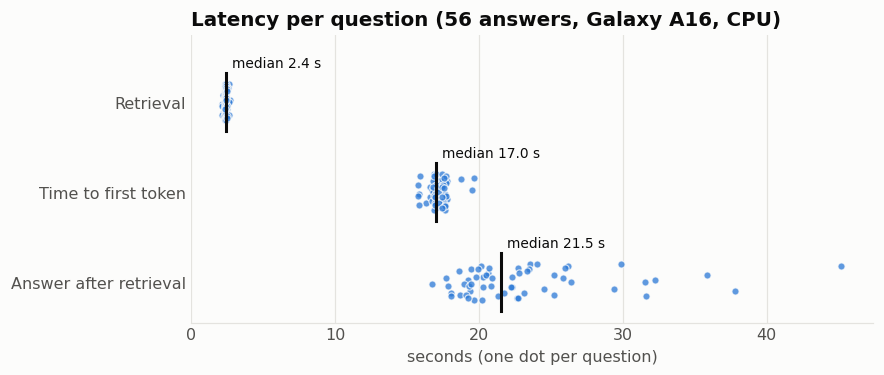

In [6]:
rows = [('Retrieval', retrieval_s), ('Time to first token', ttft), ('Answer after retrieval', total)]

fig, ax = plt.subplots(figsize=(8, 3.4))
for y, (label, values) in enumerate(rows):
    # Deterministic jitter so reruns give the same picture.
    offsets = [((i * 37) % 21 - 10) / 50 for i in range(len(values))]
    ax.scatter(values, [y + o for o in offsets], s=22, color=SERIES['vector'], alpha=0.75,
               edgecolor=SURFACE, linewidth=0.8, zorder=3)
    m = statistics.median(values)
    ax.plot([m, m], [y - 0.32, y + 0.32], color=INK, linewidth=2, zorder=4)
    # Label just above the row (the y axis is inverted), clear of the dots.
    ax.annotate(f'median {m:.1f} s', (m, y - 0.32), xytext=(4, 2), textcoords='offset points',
                ha='left', va='bottom', fontsize=9, color=INK)

ax.set_yticks(range(len(rows)), [r[0] for r in rows])
ax.set_ylim(-0.75, len(rows) - 0.55)
ax.invert_yaxis()
ax.set_xlim(0, max(total) * 1.05)
ax.set_xlabel('seconds (one dot per question)')
ax.grid(axis='y', visible=False)
ax.set_title(f'Latency per question ({len(generated)} answers, Galaxy A16, CPU)')
save(fig, 'latency_distribution.png')
plt.show()

Time to first token barely moves (all prompts fall in the model's 1,024-token prefill step, see below); the spread of the total comes from answer length. The outliers on the right are long answers, not slow prefill.

## Prefill: time to first token against prompt size

The model file was exported with fixed prefill sizes and LiteRT-LM pads every prompt up to the next one, so time to first token is a staircase. This is what set the 1,000-token prompt budget.

1 run(s) above 60 s not shown (outlier at [2496] tokens)
saved docs/charts/ttft_vs_prompt_size.png


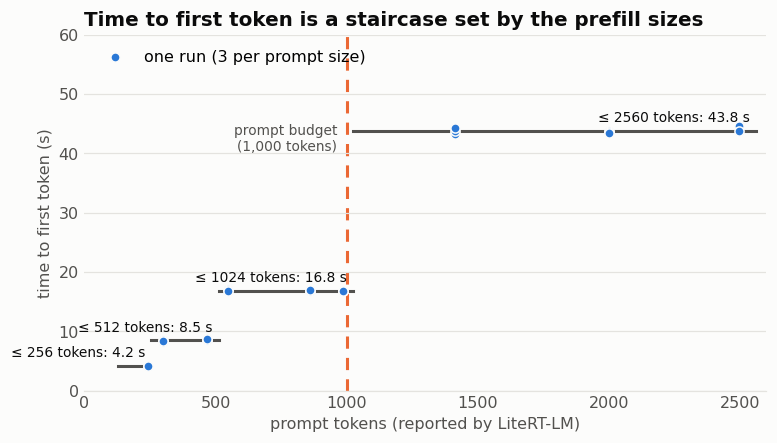

In [7]:
PREFILL_STEPS = [32, 64, 128, 256, 512, 1024, 2560]

runs = sweep['runs']
xs = [r['prompt_tokens'] for r in runs]
ys = [r['ttft_ms'] / 1000 for r in runs]

# Median time per step, drawn as a flat segment across the prompt sizes that use it.
by_step = {}
for x, y in zip(xs, ys):
    by_step.setdefault(next(s for s in PREFILL_STEPS if x <= s), []).append(y)

fig, ax = plt.subplots(figsize=(8, 4.2))
lo = 0
for step in PREFILL_STEPS:
    if step in by_step:
        m = statistics.median(by_step[step])
        ax.plot([lo, step], [m, m], color=INK_2, linewidth=2, zorder=2)
        ax.annotate(f'≤ {step} tokens: {m:.1f} s', (step, m), xytext=(-4, 6),
                    textcoords='offset points', ha='right', fontsize=9, color=INK)
    lo = step
ax.scatter(xs, ys, s=36, color=SERIES['vector'], edgecolor=SURFACE, linewidth=1, zorder=3,
           label='one run (3 per prompt size)')
top = min(max(ys) * 1.1, 60)
ax.axvline(1000, color=SERIES['hybrid'], linewidth=2, linestyle=(0, (4, 3)), zorder=1)
ax.annotate('prompt budget\n(1,000 tokens)', (1000, top * 0.75), xytext=(-6, 0),
            textcoords='offset points', ha='right', va='top', fontsize=9, color=INK_2)
ax.set_xlim(0, 2600)
ax.set_ylim(0, top)
ax.set_xlabel('prompt tokens (reported by LiteRT-LM)')
ax.set_ylabel('time to first token (s)')
ax.grid(axis='x', visible=False)
ax.legend(loc='upper left')
ax.set_title('Time to first token is a staircase set by the prefill sizes')
clipped = [x for x, y in zip(xs, ys) if y > 60]
if clipped:
    print(f'{len(clipped)} run(s) above 60 s not shown (outlier at {clipped} tokens)')
save(fig, 'ttft_vs_prompt_size.png')
plt.show()

## Hand grades (task 4.2)

Reads `eval/results/grades.json` when it exists, keyed by question id:

```json
{"q01": {"grade": "correct", "citation": "right"},
 "u02": {"grade": "wrong", "citation": "none"}}
```

- `grade`: `correct`, `partial`, `wrong` or `declined` (the reply was "not found", from the gate or the model).
- `citation`: `right` (cites a source that supports the answer), `wrong` (cites only sources that don't), or `none`.

It fills the "Answers" table of METRICS.md.

In [8]:
grades_file = RESULTS / 'grades.json'
if not grades_file.exists():
    print('No eval/results/grades.json yet: hand grades not exported.')
else:
    grades = load(grades_file)
    missing = [r['id'] for r in res if r['id'] not in grades]
    if missing:
        print(f'{len(missing)} question(s) not graded: {", ".join(missing)}')

    def count(rows, grade):
        return sum(grades.get(r['id'], {}).get('grade') == grade for r in rows)

    cited = [r for r in answerable if grades.get(r['id'], {}).get('citation') in ('right', 'wrong')]
    right = sum(grades[r['id']]['citation'] == 'right' for r in cited)
    n = len(answerable)
    table = [
        '| Correct | Partial | Wrong | Declined (answerable) | Citation accuracy | Correct refusals (of 10) |',
        '|---|---|---|---|---|---|',
        f"| {count(answerable, 'correct')}/{n} | {count(answerable, 'partial')}/{n} | {count(answerable, 'wrong')}/{n} "
        f"| {count(answerable, 'declined')}/{n} | {right}/{len(cited)} cited answers "
        f"| {count(unanswerable, 'declined')}/{len(unanswerable)} |",
    ]
    display(Markdown('\n'.join(table)))

No eval/results/grades.json yet: hand grades not exported.
